# **Importing the required libraries**

In [1]:
import os, shutil, numpy as np, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.resnet50 import preprocess_input
from google.colab import drive

# **Data Loading as in  the  SimCLR_MultiView_FeatureLearning.ipynb notebook**

In [2]:
drive.mount('/content/drive', force_remount=True)

LOCAL_PATH = "/content/ADNI_MultiView_Dataset"
if not os.path.exists(LOCAL_PATH):
    shutil.copytree("/content/drive/MyDrive/ADNI_MultiView_Dataset", LOCAL_PATH)


IMG_SIZE = 224
BATCH_SIZE_FUSION = 16

Mounted at /content/drive


In [3]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    return tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

def load_multiview_dataset(path):

    target_classes = ["AD", "CN"]
    data = []
    for label, cls in enumerate(target_classes):
        cls_path = os.path.join(path, cls)
        if not os.path.exists(cls_path): continue
        patient_dict = {}
        for file in os.listdir(cls_path):
            if not file.lower().endswith(".png"): continue
            pid = file.split("_brain_norm_")[0]
            if pid not in patient_dict: patient_dict[pid] = {}
            for v in ["axial", "sag", "cor"]:
                if v in file.lower(): patient_dict[pid][v] = os.path.join(cls_path, file)
        for pid, views in patient_dict.items():
            if len(views) == 3: data.append((views["axial"], views["sag"], views["cor"], label))
    return data, target_classes

def process_fusion(axial, sag, cor, label):
    def prep(p): return preprocess_input(load_image(p))
    return {"axial_input": prep(axial), "sagittal_input": prep(sag), "coronal_input": prep(cor)}, label

def build_fusion_ds(data, training=True):
    ax, sg, cr = [tf.constant([x[i] for x in data], dtype=tf.string) for i in range(3)]
    lbls = tf.constant([x[3] for x in data], dtype=tf.int32)
    ds = tf.data.Dataset.from_tensor_slices((ax, sg, cr, lbls)).map(process_fusion)
    if training: ds = ds.shuffle(1000).repeat()
    return ds.batch(BATCH_SIZE_FUSION).prefetch(tf.data.AUTOTUNE)

In [4]:
train_data, CLASS_NAMES = load_multiview_dataset(os.path.join(LOCAL_PATH, "train"))
val_data, _ = load_multiview_dataset(os.path.join(LOCAL_PATH, "val"))
test_data, _ = load_multiview_dataset(os.path.join(LOCAL_PATH, "test"))

train_ds = build_fusion_ds(train_data, training=True)
val_ds = build_fusion_ds(val_data, training=False)

# **Loading the Pre-trained SimCLR encoder from the SimCLR_MultiView_FeatureLearning.ipynb notebook**

In [5]:
from tensorflow.keras.models import load_model

# Load previously trained SimCLR + fusion model
saved_path = '/content/drive/MyDrive/ADNI_SimCLR_MultiView_Final.h5'
full_saved_model = load_model(saved_path)

# Extract encoder (feature extractor)
encoder = full_saved_model.get_layer("Encoder")

# Freeze encoder to preserve learned representations
encoder.trainable = False

# **Custom SOM Layer**

In [8]:
class SOMLayer(layers.Layer):
  """
    Self-Organizing Map layer:
    Learns prototype vectors and computes distance
    between input features and prototypes
    """
  def __init__(self, map_size=(10, 10), **kwargs):
    super(SOMLayer, self).__init__(**kwargs)
    self.map_size = map_size
    self.n_nodes = map_size[0] * map_size[1]
  def build(self, input_shape):
    self.prototypes = self.add_weight(name='prototypes', shape=(self.n_nodes, input_shape[-1]),
                                      initializer='random_normal', trainable=True)
    super(SOMLayer, self).build(input_shape)
  def call(self, inputs):
    diff = tf.expand_dims(inputs, axis=1) - self.prototypes
    return tf.math.sqrt(tf.reduce_sum(tf.square(diff), axis=-1) + 1e-8)

# **Hybrid Model Architechture (CNN-SOM)**

In [9]:
in_a, in_s, in_c = [layers.Input(shape=(224,224,3), name=n) for n in ["axial_input", "sagittal_input", "coronal_input"]]
merged = layers.Concatenate()([encoder(in_a), encoder(in_s), encoder(in_c)])
x = layers.Dense(128, activation='relu')(merged)
x = layers.BatchNormalization()(x)
som_dists = SOMLayer(map_size=(10, 10), name="SOM_Layer")(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(som_dists)

hybrid_som_model = Model(inputs=[in_a, in_s, in_c], outputs=outputs)

In [10]:
#Compile
hybrid_som_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [11]:
#Train
hybrid_som_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, steps_per_epoch=len(train_data)//BATCH_SIZE_FUSION)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 72s 605ms/step - accuracy: 0.5981 - loss: 1.4183 - val_accuracy: 0.6723 - val_loss: 0.6164
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.8869 - loss: 0.4727 - val_accuracy: 0.7563 - val_loss: 0.5547
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9526 - loss: 0.3469 - val_accuracy: 0.7311 - val_loss: 0.5581
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.9741 - loss: 0.2531 - val_accuracy: 0.7395 - val_loss: 0.5892
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.9763 - loss: 0.1925 - val_accuracy: 0.7227 - val_loss: 0.5915
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9828 - loss: 0.1499 - val_accuracy: 0.7563 - val_loss: 0.6199
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9881 - loss: 0.1184 - val_accuracy: 0.7395 - val_loss: 0.6951
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.9914 - loss: 0.1008 - val_accurac

In [12]:
import os

# Folder for visual results
SAVE_DIR = '/content/drive/MyDrive/Thesis_Results_Final'
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

def save_thesis_plot(filename):
    path = os.path.join(SAVE_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {path}")

# **Visualization**

##U-MATRIX heatmap (SOM TOPOLOGY)

✅ Saved: /content/drive/MyDrive/Thesis_Results_Final/Figure_1_UMatrix_Heatmap.png


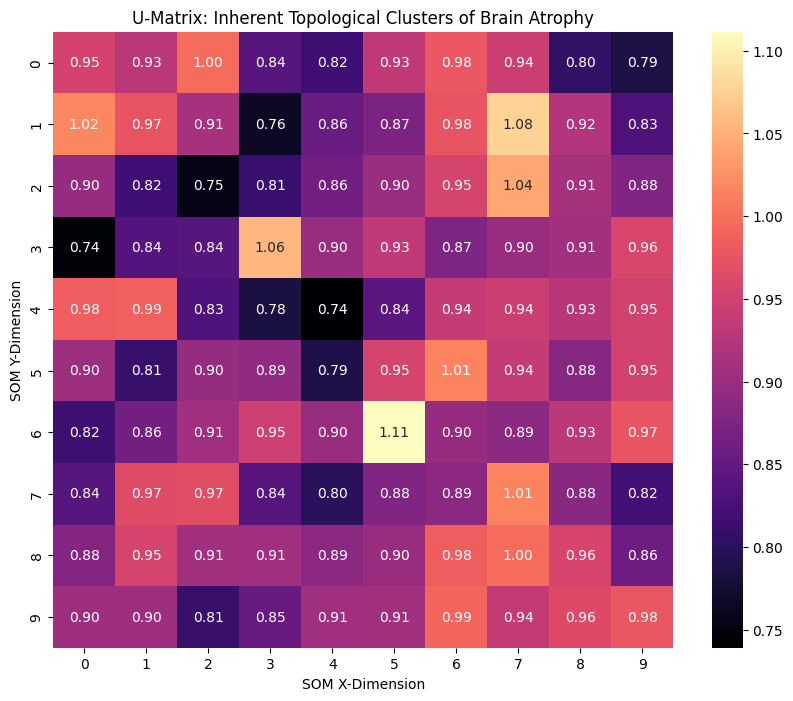

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def generate_som_viz(model):
    # Extract and reshape prototype weights to (10, 10, feature_dim)
    weights = model.get_layer("SOM_Layer").get_weights()[0]
    map_size = (10, 10)
    grid = weights.reshape(map_size[0], map_size[1], -1)

    #Compute mean distance to cardinal neighbours for each node
    u_matrix = np.zeros(map_size)
    for y in range(map_size[0]):
        for x in range(map_size[1]):
            dists = []
            if x > 0: dists.append(np.linalg.norm(grid[y,x] - grid[y, x-1]))
            if x < 9: dists.append(np.linalg.norm(grid[y,x] - grid[y, x+1]))
            if y > 0: dists.append(np.linalg.norm(grid[y,x] - grid[y-1, x]))
            if y < 9: dists.append(np.linalg.norm(grid[y,x] - grid[y+1, x]))
            u_matrix[y,x] = np.mean(dists)

    # U-matrix Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(u_matrix, cmap='magma', annot=True, fmt=".2f")
    plt.title("U-Matrix: Inherent Topological Clusters of Brain Atrophy")
    plt.xlabel("SOM X-Dimension")
    plt.ylabel("SOM Y-Dimension")
    save_thesis_plot('Figure_1_UMatrix_Heatmap.png')
    plt.show()

generate_som_viz(hybrid_som_model)

## Class Territory Map

Mapping test patients to SOM grid...
✅ Saved: /content/drive/MyDrive/Thesis_Results_Final/Figure_2_SOM_Territory_Map.png


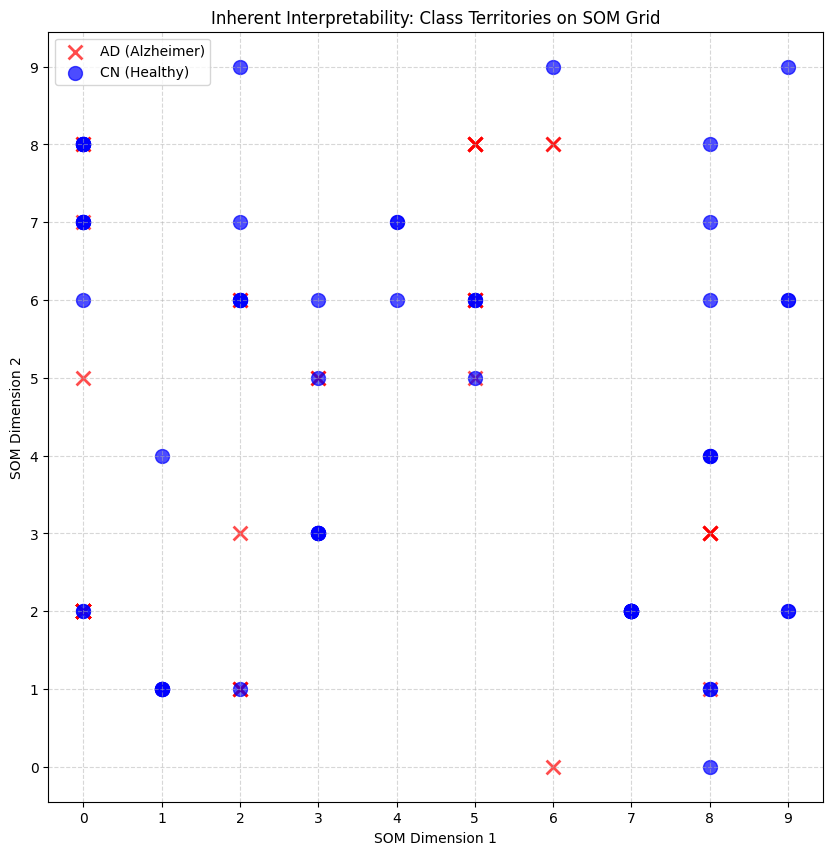

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_territories(model, dataset):
    # Get the feature extractor output before the SOM layer..
    feature_extractor = Model(inputs=model.input, outputs=model.get_layer("batch_normalization").output)

    som_weights = model.get_layer("SOM_Layer").get_weights()[0]
    class_map = {0: [], 1: []} # 0 for AD, 1 for CN

    print("Mapping test patients to SOM grid...")
    for inputs, labels in dataset:
        feats = feature_extractor.predict(inputs, verbose=0)

        for i, f in enumerate(feats):
            # Find Best Matching Unit (BMU)
            dists = np.linalg.norm(som_weights - f, axis=1)
            bmu = np.argmin(dists)

            y, x = divmod(bmu, 10)
            class_map[labels[i].numpy()].append((x, y))

    # Plotting
    plt.figure(figsize=(10, 10))

    ad_pts = np.array(class_map[0])
    cn_pts = np.array(class_map[1])

    if len(ad_pts) > 0:
        plt.scatter(ad_pts[:, 0], ad_pts[:, 1], c='red', label='AD (Alzheimer)',
                    alpha=0.7, marker='x', s=100, linewidths=2)
    if len(cn_pts) > 0:
        plt.scatter(cn_pts[:, 0], cn_pts[:, 1], c='blue', label='CN (Healthy)',
                    alpha=0.7, marker='o', s=100)

    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.title("Inherent Interpretability: Class Territories on SOM Grid")
    plt.xlabel("SOM Dimension 1")
    plt.ylabel("SOM Dimension 2")
    save_thesis_plot('Figure_2_SOM_Territory_Map.png')
    plt.legend()
    plt.show()

test_ds = build_fusion_ds(test_data, training=False)
plot_class_territories(hybrid_som_model, test_ds)

# **Evaluation**

In [18]:
from sklearn.metrics import classification_report

y_true, y_pred = [], []
for inputs, labels in test_ds:
    preds = hybrid_som_model.predict(inputs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n SOM-HYBRID FINAL REPORT")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


 SOM-HYBRID FINAL REPORT
              precision    recall  f1-score   support

          AD       0.79      0.62      0.70        48
          CN       0.78      0.89      0.83        73

    accuracy                           0.79       121
   macro avg       0.79      0.76      0.77       121
weighted avg       0.79      0.79      0.78       121



## Confusion Matrix

✅ Saved: /content/drive/MyDrive/Thesis_Results_Final/Figure_4_Confusion_Matrix.png


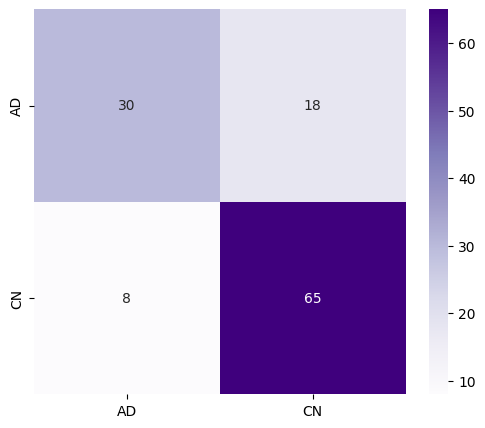

In [19]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
save_thesis_plot('Figure_4_Confusion_Matrix.png')
plt.show()

## GRAD-CAM: Local Saliency (Where the model looks)

In [20]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):

    encoder = model.get_layer("Encoder")
    grad_model = tf.keras.models.Model(
        [encoder.inputs], [encoder.get_layer(last_conv_layer_name).output, encoder.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0] # Focus on AD class

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap))
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    # Get original image dimensions
    # img is the raw numpy array from Gradio (H, W, C)
    height, width = img.shape[0], img.shape[1]

    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply the jet colormap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match the ORIGINAL image dimensions
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap).resize((width, height))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Blend the images
    superimposed_img = jet_heatmap * alpha + img
    return tf.keras.utils.array_to_img(superimposed_img)

## Build SOM Node ATLAS (BMU + Training Image Lookup Table)

In [22]:
#Create a feature extractor that stops at the SOM input
feature_extractor = Model(inputs=hybrid_som_model.input,
                          outputs=hybrid_som_model.get_layer("batch_normalization").output)

# Get the SOM weights (the centers of each node)
som_weights = hybrid_som_model.get_layer("SOM_Layer").get_weights()[0]

# Map all training images to their Best Matching Unit (BMU)
node_to_image_paths = {i: [] for i in range(100)} # For a 10x10 grid

print("Mapping training set to SOM nodes...")
for i in range(len(train_data)):
    # Prepare the 3 views for one patient
    axial, sag, cor, label = train_data[i]

    inputs, _ = process_fusion(axial, sag, cor, label)
    inputs = {k: tf.expand_dims(v, 0) for k, v in inputs.items()}

    # Get features and find BMU
    feats = feature_extractor.predict(inputs, verbose=0)
    dists = np.linalg.norm(som_weights - feats, axis=1)
    bmu = np.argmin(dists)

    # Store the paths so we can display them later
    node_to_image_paths[bmu].append(axial) # Storing axial view as the primary reference

Mapping training set to SOM nodes...


## Case-Based Explanation (Human Explanation)

✅ Saved: /content/drive/MyDrive/Thesis_Results_Final/Figure_3_Case_Based_Explanation.png


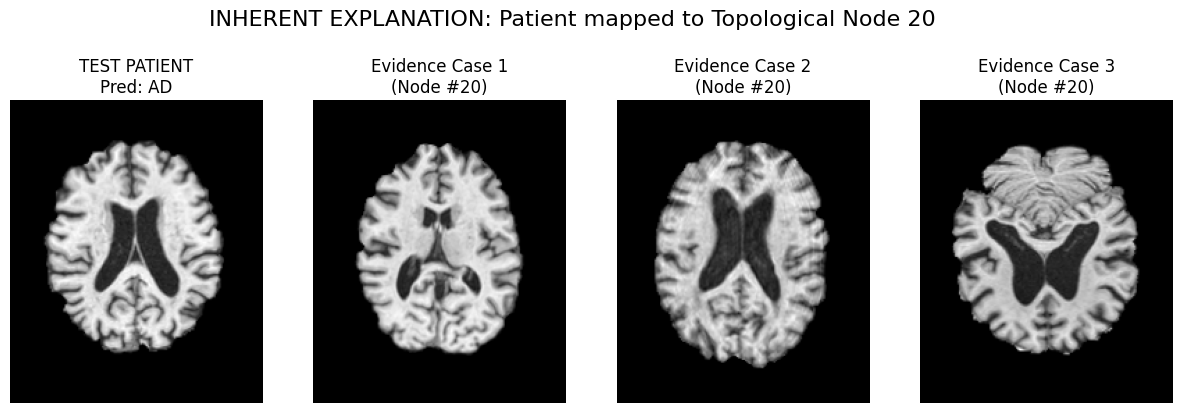

In [23]:
def explain_like_a_doctor(patient_index, test_data_list, node_lookup):
    #Get the patient's views
    axial, sag, cor, true_label = test_data_list[patient_index]
    inputs, _ = process_fusion(axial, sag, cor, true_label)
    inputs = {k: tf.expand_dims(v, 0) for k, v in inputs.items()}

    #Get Prediction and BMU
    preds = hybrid_som_model.predict(inputs, verbose=0)
    pred_label = np.argmax(preds)

    feats = feature_extractor.predict(inputs, verbose=0)
    dists = np.linalg.norm(som_weights - feats, axis=1)
    bmu = np.argmin(dists)

    #Pull the "Evidence" from the lookup table
    evidence_paths = node_lookup[bmu][:3] # Get up to 3 images

    # 4. Visualization
    plt.figure(figsize=(15, 5))

    # Show the Test Patient
    plt.subplot(1, 4, 1)
    plt.imshow(plt.imread(axial), cmap='gray')
    plt.title(f"TEST PATIENT\nPred: {CLASS_NAMES[pred_label]}")
    plt.axis('off')

    # Show the Evidence
    for i, path in enumerate(evidence_paths):
        plt.subplot(1, 4, i+2)
        plt.imshow(plt.imread(path), cmap='gray')
        plt.title(f"Evidence Case {i+1}\n(Node #{bmu})")
        plt.axis('off')

    plt.suptitle(f"INHERENT EXPLANATION: Patient mapped to Topological Node {bmu}", fontsize=16)
    save_thesis_plot('Figure_3_Case_Based_Explanation.png')
    plt.show()

# Explains the 5th patient in test set
explain_like_a_doctor(5, test_data, node_to_image_paths)

## Interpretability Comparison (LIME vs SOM)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Thesis_Results_Final/Comparison_Patient_10.png


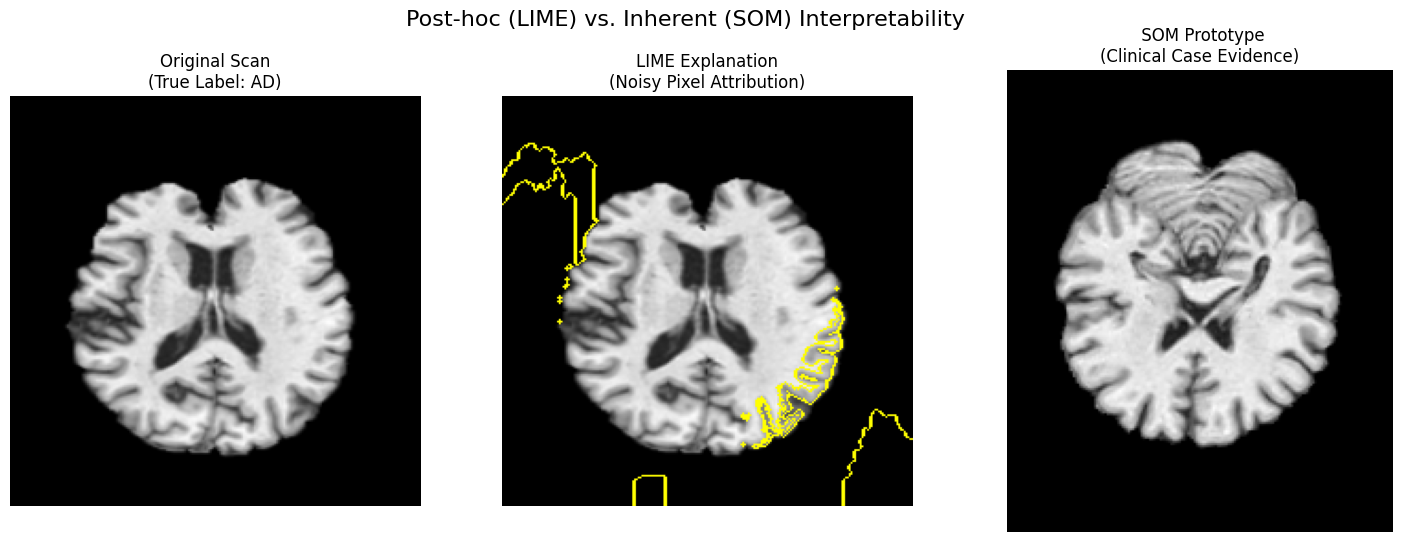

In [24]:
!pip install lime shap -q
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
import matplotlib.pyplot as plt
import numpy as np

def generate_comparison_report(patient_index, test_data_list):
    # Setup Patient Data
    axial_path, sag_path, cor_path, label = test_data_list[patient_index]
    axial_img = load_image(axial_path).numpy()

    # Preprocess for model
    def p(img_array):

        if img_array.ndim == 2:  # Grayscale image (H, W)
            img_array = np.stack([img_array, img_array, img_array], axis=-1)  # Convert to (H, W, 3)
        elif img_array.ndim == 4: # RGBA image (H, W, 4)
            img_array = img_array[:,:,:3] # Convert to (H, W, 3) by dropping alpha channel
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        return preprocess_input(tf.image.resize(img_tensor, (224,224)))

    in_a, in_s, in_c = [tf.expand_dims(p(plt.imread(path)), 0) for path in [axial_path, sag_path, cor_path]]

    # 2. LIME Explanation (The "Baseline")
    explainer = lime_image.LimeImageExplainer()


    def predict_fn(images):
        # We assume the model sees 3 identical views for the LIME perturbation
        imgs = preprocess_input(images)
        return hybrid_som_model.predict([imgs, imgs, imgs], verbose=0)

    explanation = explainer.explain_instance(axial_img.astype('double'),
                                            predict_fn, top_labels=1,
                                            hide_color=0, num_samples=500)
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                                positive_only=True, num_features=5, hide_rest=False)

    # 3. Visualization
    plt.figure(figsize=(18, 6))

    # Subplot 1: The Input
    plt.subplot(1, 3, 1)
    plt.imshow(axial_img/255.0 if axial_img.max() > 1 else axial_img)
    plt.title(f"Original Scan\n(True Label: {CLASS_NAMES[label]})")
    plt.axis('off')

    # Subplot 2: LIME (Post-hoc)
    plt.subplot(1, 3, 2)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title("LIME Explanation\n(Noisy Pixel Attribution)")
    plt.axis('off')

    # Subplot 3: SOM Prototype (Inherent)
    plt.subplot(1, 3, 3)
    dist_model = Model(inputs=hybrid_som_model.input, outputs=hybrid_som_model.get_layer("SOM_Layer").output)
    dists = dist_model.predict([in_a, in_s, in_c], verbose=0)
    bmu = np.argmin(dists[0])
    evidence = plt.imread(node_to_image_paths[bmu][0])
    plt.imshow(evidence, cmap='gray')
    plt.title(f" SOM Prototype\n(Clinical Case Evidence)")
    plt.axis('off')

    plt.suptitle("Post-hoc (LIME) vs. Inherent (SOM) Interpretability", fontsize=16)
    save_thesis_plot(f'Comparison_Patient_{patient_index}.png')
    plt.show()


generate_comparison_report(10, test_data)

#GUI

In [25]:
import gradio as gr

def predict_explain_ultimate(axial_img, sag_img, cor_img):
    try:
        # Preprocess
        def p(img):
            return preprocess_input(tf.image.resize(tf.convert_to_tensor(img, dtype=tf.float32), (224,224)))

        in_a = tf.expand_dims(p(axial_img), 0)
        in_s = tf.expand_dims(p(sag_img), 0)
        in_c = tf.expand_dims(p(cor_img), 0)

        # Get Prediction
        preds = hybrid_som_model.predict([in_a, in_s, in_c], verbose=0)
        prob_ad = float(preds[0][0])
        label_str = "AD" if prob_ad > 0.5 else "CN"

        # Generate Grad-CAM (The 'Where')
        # Using the Axial view as the primary saliency reference
        heatmap = make_gradcam_heatmap(in_a, hybrid_som_model)
        cam_result = display_gradcam(axial_img, heatmap)

        # Get SOM Evidence (The 'What')
        dist_model = Model(inputs=hybrid_som_model.input, outputs=hybrid_som_model.get_layer("SOM_Layer").output)
        dists = dist_model.predict([in_a, in_s, in_c], verbose=0)
        bmu = np.argmin(dists[0])

        evidence_list = []
        if bmu in node_to_image_paths and node_to_image_paths[bmu]:
            paths = node_to_image_paths[bmu][:3]
            for path in paths:
                evidence_list.append(plt.imread(path))

        while len(evidence_list) < 3:
            evidence_list.append(np.zeros((224,224,3)))

        return (
            {"Alzheimer (AD)": prob_ad, "Healthy (CN)": 1-prob_ad},
            cam_result, # The Heatmap
            f"Node #{bmu}: Atrophy Pattern Identified",
            evidence_list[0], evidence_list[1], evidence_list[2]
        )
    except Exception as e:
        return None, None, f"Error: {str(e)}", None, None, None


with gr.Blocks(css=".gradio-container {background-color: #121212; color: #ff8c00;}") as demo:
    gr.Markdown("<h1 style='color: #ff8c00; text-align: center;'>Hybrid CNN-SOM Clinical Dashboard</h1>")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("<h4 style='color: #ff8c00;'>1. Patient Input</h4>")
            a, s, c = gr.Image(label="Axial"), gr.Image(label="Sagittal"), gr.Image(label="Coronal")
            go = gr.Button("RUN DIAGNOSTICS ", variant="primary")

        with gr.Column(scale=2):
            gr.Markdown("<h4 style='color: #ff8c00;'>2. Local Saliency (Grad-CAM)</h4>")
            # This shows WHERE the model is looking
            out_cam = gr.Image(label="Focus Regions (Heatmap)")

            gr.Markdown("<h4 style='color: #ff8c00;'>3. Prediction & Reasoning</h4>")
            out_label = gr.Label(num_top_classes=2)
            out_txt = gr.Textbox(label="Topological Mapping")

            gr.Markdown("<h4 style='color: #ff8c00;'>4. Global Evidence (SOM Prototypes)</h4>")
            # This shows WHAT the model is comparing it to
            with gr.Row():
                ev1 = gr.Image(label="Ref 1")
                ev2 = gr.Image(label="Ref 2")
                ev3 = gr.Image(label="Ref 3")

    go.click(predict_explain_ultimate, [a, s, c], [out_label, out_cam, out_txt, ev1, ev2, ev3])

demo.launch(share=True)

/tmp/ipykernel_14107/124136618.py:47: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=".gradio-container {background-color: #121212; color: #ff8c00;}") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd4b985de2b3d356c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
